# Automobile Price Analysis — EDA and Data Preparation

## Objective
This notebook explores the UCI Automobile dataset, documents data quality, and prepares a cleaned dataset for clustering and price-prediction modeling.

## Analytical question
Which vehicle characteristics appear to be associated with automobile price?


## Project structure

```text
automobile-price-analysis/
├── data/
│   ├── raw/
│   │   └── imports-85.data
│   └── processed/
└── notebooks/
    └── 01_eda_preprocessing.ipynb
```

The notebook expects the source data at `data/raw/imports-85.data`.


## Imports and configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='deep')


## Load raw data

The original UCI Automobile file does not include column names and represents missing values with `?`. The import settings below assign clear column names and convert `?` to missing values.


In [2]:
columns = [
    'symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration',
    'num_of_doors', 'body_style', 'drive_wheels', 'engine_location',
    'wheel_base', 'length', 'width', 'height', 'curb_weight',
    'engine_type', 'num_of_cylinders', 'engine_size', 'fuel_system',
    'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm',
    'city_mpg', 'highway_mpg', 'price'
]

raw_path = Path('../data/raw/imports-85.data')

if not raw_path.exists():
    raise FileNotFoundError(
        f'File not found: {raw_path.resolve()}\n'
        'Expected location: data/raw/imports-85.data'
    )

df_raw = pd.read_csv(raw_path, header=None, names=columns, na_values='?')

print(f'Loaded {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.')
display(df_raw.head())


Loaded 205 rows and 26 columns.


,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


## Data-quality audit

The initial audit checks data types, missing values, unique values, and exact duplicates before any cleaning decisions are made.


In [3]:
quality_report = pd.DataFrame({
    'dtype': df_raw.dtypes.astype(str),
    'missing_values': df_raw.isna().sum(),
    'missing_pct': (df_raw.isna().mean() * 100).round(1),
    'unique_values': df_raw.nunique()
}).sort_values('missing_values', ascending=False)

quality_report


,dtype,missing_values,missing_pct,unique_values
normalized_losses,float64,41,20.0,51
stroke,float64,4,2.0,36
price,float64,4,2.0,186
bore,float64,4,2.0,38
horsepower,float64,2,1.0,59
peak_rpm,float64,2,1.0,23
num_of_doors,str,2,1.0,2
symboling,int64,0,0.0,6
fuel_type,str,0,0.0,2
make,str,0,0.0,22


In [4]:
n_rows_raw, n_columns_raw = df_raw.shape
duplicate_count = int(df_raw.duplicated().sum())
missing_cols = quality_report.query('missing_values > 0').index.tolist()
missing_text = ', '.join(missing_cols) if missing_cols else 'None'

summary = f'''### Data-quality findings

- The raw dataset contains **{n_rows_raw:,} rows** and **{n_columns_raw} columns**.
- Columns with missing values: **{missing_text}**.
- Exact duplicate rows: **{duplicate_count:,}**.
- Numeric measurement columns are converted in the next section so they can be analyzed correctly.
'''
display(Markdown(summary))


### Data-quality findings

- The raw dataset contains **205 rows** and **26 columns**.
- Columns with missing values: **normalized_losses, stroke, price, bore, horsepower, peak_rpm, num_of_doors**.
- Exact duplicate rows: **0**.
- Numeric measurement columns are converted in the next section so they can be analyzed correctly.


## Convert numeric columns

Several measurements may initially be stored as text because of missing values in the raw file. Invalid numeric values are converted to `NaN` so that they remain visible during analysis.


In [5]:
numeric_columns = [
    'normalized_losses', 'wheel_base', 'length', 'width', 'height',
    'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio',
    'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price'
]

for col in numeric_columns:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

df_raw[numeric_columns].dtypes.to_frame('dtype')


,dtype
normalized_losses,float64
wheel_base,float64
length,float64
width,float64
height,float64
curb_weight,int64
engine_size,int64
bore,float64
stroke,float64
compression_ratio,float64


## Price distribution

`price` is the target variable for later regression modeling because it is a continuous numerical outcome.


,price
count,201.000000
mean,13207.129353
std,7947.066342
min,5118.000000
25%,7775.000000
50%,10295.000000
75%,16500.000000
max,45400.000000


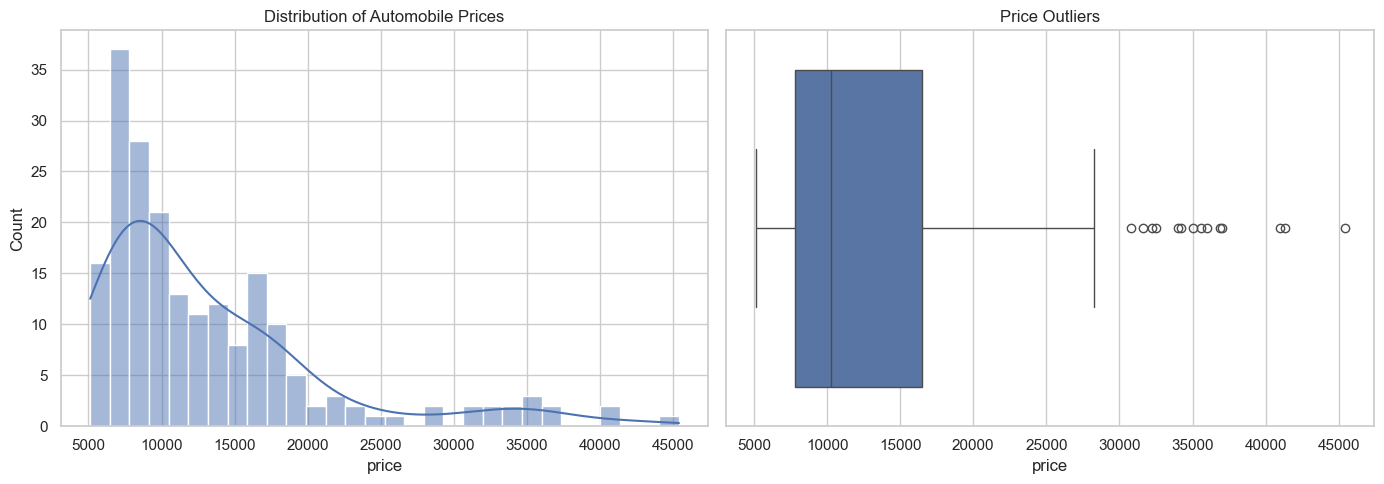

In [6]:
display(df_raw['price'].describe().to_frame('price'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_raw, x='price', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Automobile Prices')
sns.boxplot(data=df_raw, x='price', ax=axes[1])
axes[1].set_title('Price Outliers')
plt.tight_layout()
plt.show()


In [7]:
price_series = df_raw['price'].dropna()
price_min = price_series.min()
price_max = price_series.max()
price_median = price_series.median()
price_mean = price_series.mean()
price_skew = price_series.skew()
shape_text = 'right-skewed' if price_skew > 0.5 else ('left-skewed' if price_skew < -0.5 else 'approximately symmetric')

summary = f'''### Price distribution findings

- Price range: **${price_min:,.0f} to ${price_max:,.0f}**.
- Median price: **${price_median:,.0f}**.
- Mean price: **${price_mean:,.0f}**.
- Distribution shape: **{shape_text}** (skewness = **{price_skew:.2f}**).
'''
display(Markdown(summary))


### Price distribution findings

- Price range: **$5,118 to $45,400**.
- Median price: **$10,295**.
- Mean price: **$13,207**.
- Distribution shape: **right-skewed** (skewness = **1.81**).


## Numeric relationships with price

Correlation is used as an exploratory measure of linear association. It helps identify candidate features, but it does not establish causation.


,correlation_with_price
price,1.000000
engine_size,0.872335
curb_weight,0.834415
horsepower,0.810533
width,0.751265
length,0.690628
wheel_base,0.584642
bore,0.543436
normalized_losses,0.203254
height,0.135486


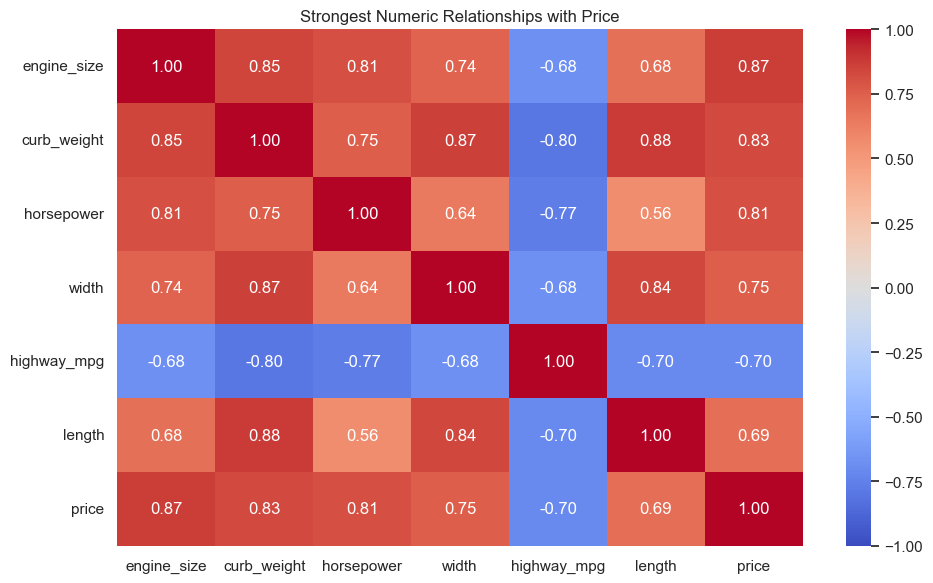

In [8]:
numeric_df = df_raw.select_dtypes(include='number')
price_correlations = numeric_df.corr(numeric_only=True)['price'].sort_values(ascending=False).to_frame('correlation_with_price')
display(price_correlations)

top_features = (
    price_correlations.drop(index='price').abs()
    .sort_values('correlation_with_price', ascending=False)
    .head(6).index.tolist()
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    df_raw[top_features + ['price']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)
plt.title('Strongest Numeric Relationships with Price')
plt.tight_layout()
plt.show()


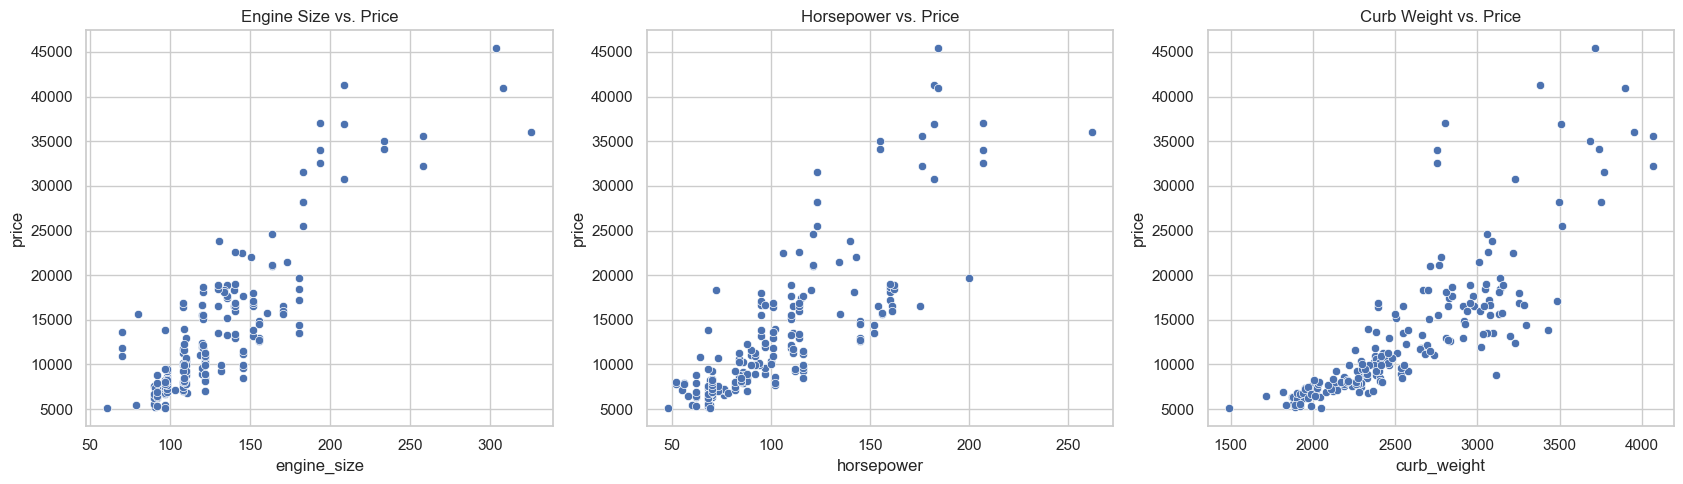

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, feature, title in zip(
    axes,
    ['engine_size', 'horsepower', 'curb_weight'],
    ['Engine Size vs. Price', 'Horsepower vs. Price', 'Curb Weight vs. Price']
):
    sns.scatterplot(data=df_raw, x=feature, y='price', ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()


In [10]:
corr_no_price = price_correlations.drop(index='price').copy()
top_corr = corr_no_price.reindex(
    corr_no_price['correlation_with_price'].abs().sort_values(ascending=False).head(5).index
)

lines = '\n'.join(
    f'- **{feature}**: correlation = **{value:.2f}**'
    for feature, value in top_corr['correlation_with_price'].items()
)

summary = f'''### Numeric relationship findings

Top numeric relationships with price:

{lines}

These variables are retained as candidates for later clustering and regression analysis.
'''
display(Markdown(summary))


### Numeric relationship findings

Top numeric relationships with price:

- **engine_size**: correlation = **0.87**
- **curb_weight**: correlation = **0.83**
- **horsepower**: correlation = **0.81**
- **width**: correlation = **0.75**
- **highway_mpg**: correlation = **-0.70**

These variables are retained as candidates for later clustering and regression analysis.


## Categorical relationships with price

Price may also differ by manufacturer, body style, drivetrain, fuel type, and aspiration.


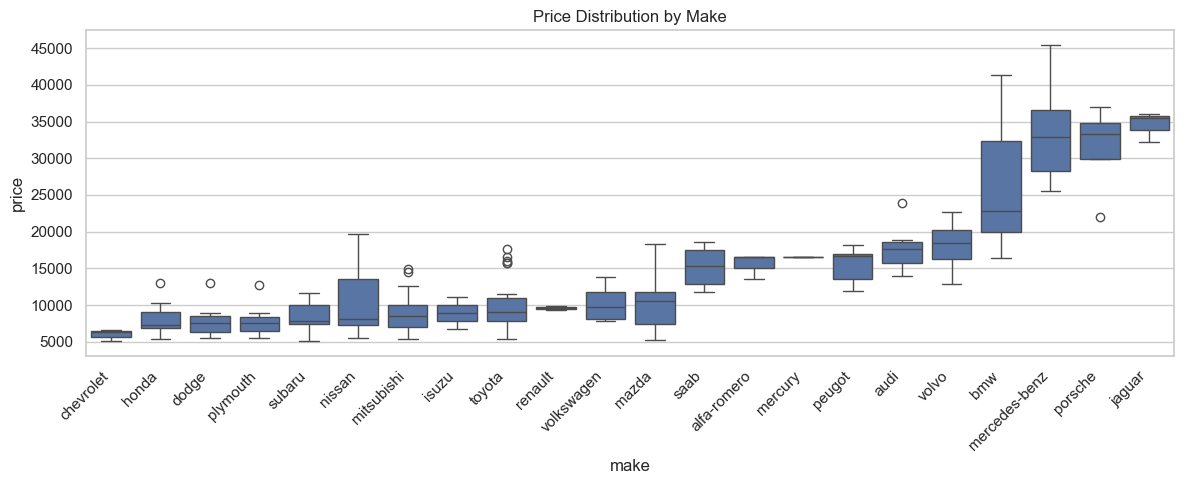

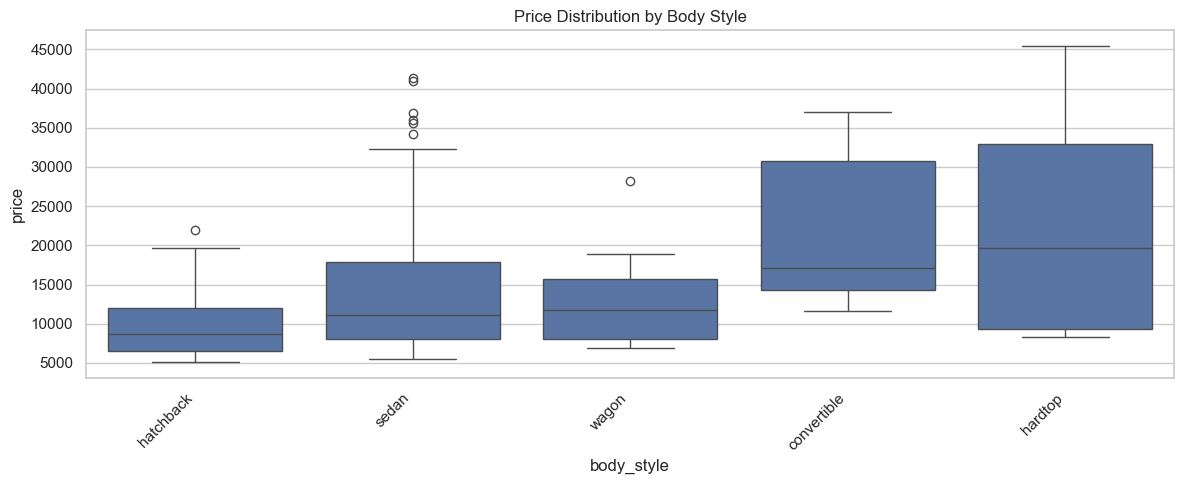

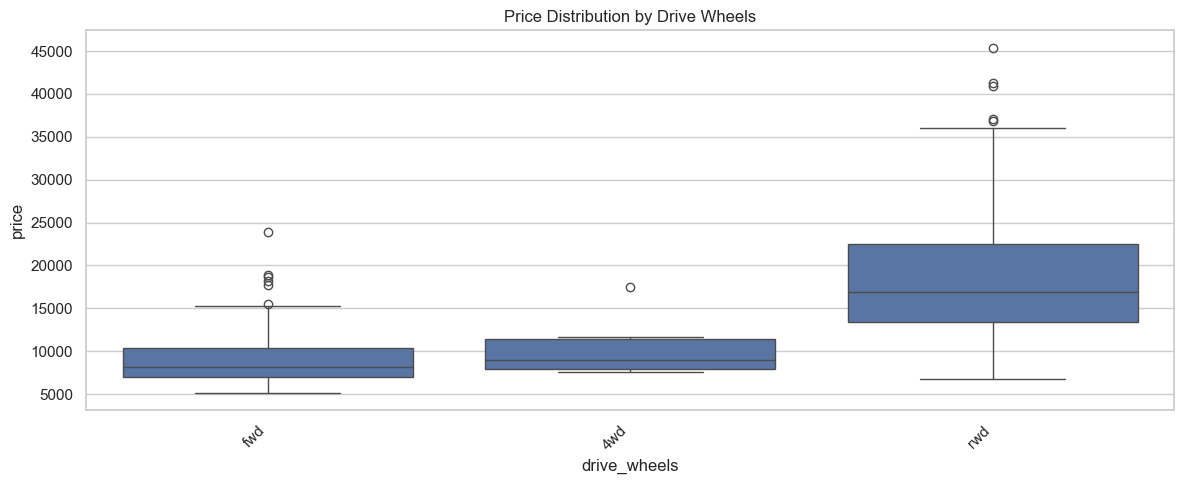

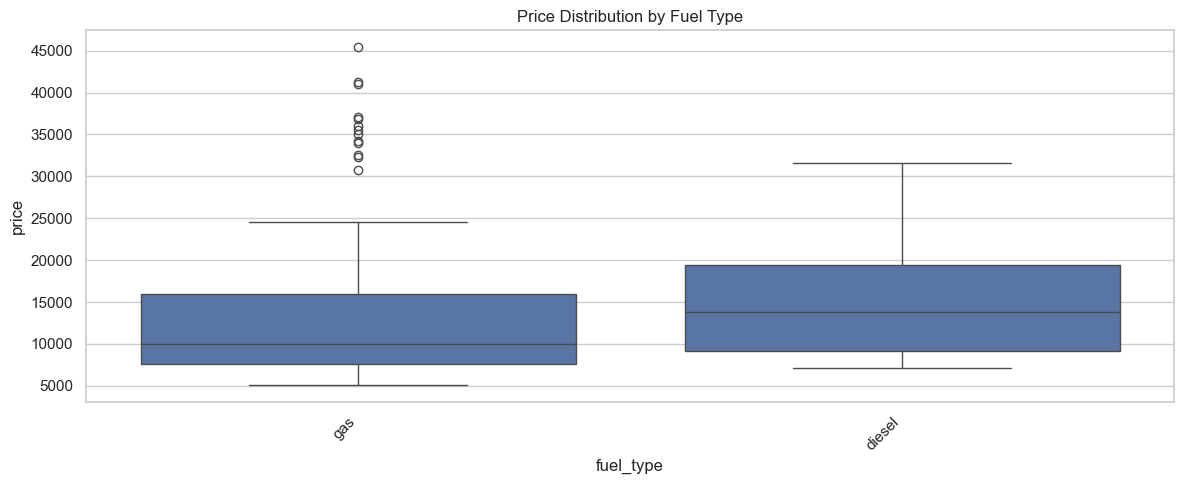

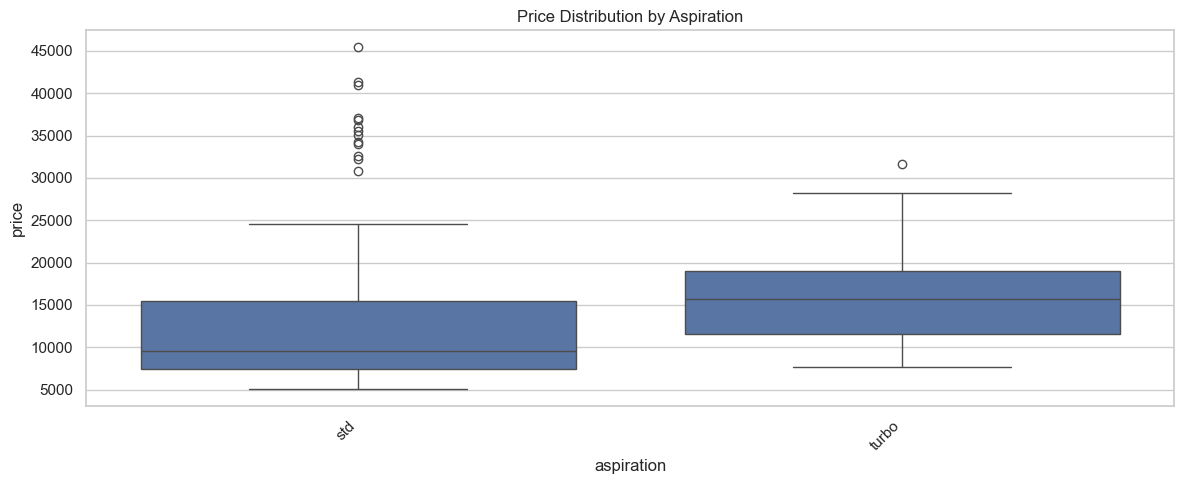

In [11]:
categorical_features = ['make', 'body_style', 'drive_wheels', 'fuel_type', 'aspiration']

for feature in categorical_features:
    plot_data = df_raw.dropna(subset=[feature, 'price'])
    order = plot_data.groupby(feature)['price'].median().sort_values().index

    plt.figure(figsize=(12, 5))
    sns.boxplot(data=plot_data, x=feature, y='price', order=order)
    plt.title(f'Price Distribution by {feature.replace("_", " " ).title()}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


In [12]:
category_results = []

for feature in categorical_features:
    medians = df_raw.groupby(feature)['price'].median().dropna()
    if not medians.empty:
        category_results.append({
            'feature': feature,
            'low_category': medians.idxmin(),
            'low_price': medians.min(),
            'high_category': medians.idxmax(),
            'high_price': medians.max(),
            'range': medians.max() - medians.min()
        })

category_summary = pd.DataFrame(category_results).sort_values('range', ascending=False)
display(category_summary)

strongest = category_summary.iloc[0]
summary = f'''### Categorical relationship finding

- The selected variable with the largest median-price range is **{strongest['feature']}**.
- Lowest median: **{strongest['low_category']}** at **${strongest['low_price']:,.0f}**.
- Highest median: **{strongest['high_category']}** at **${strongest['high_price']:,.0f}**.
'''
display(Markdown(summary))


,feature,low_category,low_price,high_category,high_price,range
0,make,chevrolet,6295.0,jaguar,35550.0,29255.0
1,body_style,hatchback,8672.0,hardtop,19687.5,11015.5
2,drive_wheels,fwd,8192.0,rwd,16900.0,8708.0
4,aspiration,std,9538.0,turbo,15686.0,6148.0
3,fuel_type,gas,9989.0,diesel,13852.5,3863.5


### Categorical relationship finding

- The selected variable with the largest median-price range is **make**.
- Lowest median: **chevrolet** at **$6,295**.
- Highest median: **jaguar** at **$35,550**.


## Data cleaning

Rows with missing `price` are removed because they cannot be used in later price modeling. Exact duplicates are also removed. Missing predictor values are retained for now and will be handled inside later preprocessing pipelines after train/test splitting.


In [13]:
rows_before = len(df_raw)
missing_price_rows = int(df_raw['price'].isna().sum())
duplicates_before = int(df_raw.duplicated().sum())

df_clean = df_raw.dropna(subset=['price']).drop_duplicates().copy()
rows_after = len(df_clean)

remaining_missing = df_clean.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
display(remaining_missing.to_frame('remaining_missing_values'))


,remaining_missing_values
normalized_losses,37
bore,4
stroke,4
num_of_doors,2
horsepower,2
peak_rpm,2


In [14]:
remaining_text = ', '.join(remaining_missing.index.tolist()) if not remaining_missing.empty else 'None'

summary = f'''### Data-cleaning summary

- Rows before cleaning: **{rows_before:,}**.
- Rows with missing price: **{missing_price_rows:,}**.
- Duplicate rows before cleaning: **{duplicates_before:,}**.
- Rows after cleaning: **{rows_after:,}**.
- Rows removed: **{rows_before - rows_after:,}**.
- Remaining missing predictor columns: **{remaining_text}**.
'''
display(Markdown(summary))


### Data-cleaning summary

- Rows before cleaning: **205**.
- Rows with missing price: **4**.
- Duplicate rows before cleaning: **0**.
- Rows after cleaning: **201**.
- Rows removed: **4**.
- Remaining missing predictor columns: **normalized_losses, bore, stroke, num_of_doors, horsepower, peak_rpm**.


## Export cleaned dataset

In [15]:
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

clean_path = processed_dir / 'automobiles_clean.csv'
df_clean.to_csv(clean_path, index=False)

print(f'Saved: {clean_path.resolve()}')
print(f'Exported shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns')


Saved: E:\GitHub\FinalTlabz\data\processed\automobiles_clean.csv
Exported shape: 201 rows × 26 columns


## EDA conclusion

In [16]:
top_three = ', '.join(top_corr.head(3).index.tolist())

summary = f'''### Summary of findings

- The cleaned dataset contains **{df_clean.shape[0]:,} records** and **{df_clean.shape[1]} columns**.
- Cleaned price range: **${df_clean['price'].min():,.0f} to ${df_clean['price'].max():,.0f}**.
- Strongest numeric candidates for future analysis: **{top_three}**.
- The cleaned file was saved successfully: **{clean_path.exists()}**.
- The next notebook will use selected technical variables to identify vehicle segments with K-Means clustering.
'''
display(Markdown(summary))


### Summary of findings

- The cleaned dataset contains **201 records** and **26 columns**.
- Cleaned price range: **$5,118 to $45,400**.
- Strongest numeric candidates for future analysis: **engine_size, curb_weight, horsepower**.
- The cleaned file was saved successfully: **True**.
- The next notebook will use selected technical variables to identify vehicle segments with K-Means clustering.


### Interpretation

The exploratory analysis shows that automobile price is mainly associated with vehicle size, engine performance, and weight. Engine size, horsepower, and curb weight showed some of the strongest relationships with price, suggesting that larger and more powerful vehicles generally tend to have higher prices.

The price distribution is right-skewed, meaning that most vehicles fall in a lower-to-middle price range while a smaller number of high-priced vehicles extend the distribution upward. Price also varies across manufacturers and other vehicle characteristics, suggesting that both technical specifications and market positioning may be useful for price prediction.

After removing records with missing prices and duplicate observations, the dataset is ready for the next stage of analysis. Remaining missing values in predictor columns will be handled through preprocessing pipelines in later notebooks to prevent data leakage.
